# Fig4_nichespace.ipynb

## Introduction
This notebook computes the PCA results of all environmental variables through 2009-2018, convert the both model prediction to nichespace and evaluate the performance. 

In [1]:
# This cell imports required modules and sets default plotting style.
# PlotUtlis, create_folder, mm2inch, set_mpl_defaults, get_significance_stars, get_performance_stats
# are custom utility methods that handle plotting, folder creation, and performance calculation.
from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, get_significance_stars, get_performance_stats

import yaml
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.decomposition import PCA
import math
import feather
import h5py
from matplotlib.colors import ListedColormap

# This function configures matplotlib default styles (like font sizes, line widths, etc.)
set_mpl_defaults()

In [2]:
# Define unique identifiers for the run and experiment.
# These IDs are typically used to retrieve specific model configurations and outputs.
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

In [3]:
# Initialize a PlotUtlis object with the run and experiment IDs.
# This object provides various utility functions for plotting and data preparation.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [4]:
# Create a folder to store niche space plots.
create_folder(PU.plot_path_nichespace)

## PCA with all environmental data

In [5]:
# Load the environmental data based on the configuration.
# This merges data from multiple months or time periods.
df_env = PU.set_df_env()

In [6]:
# Compute correlations among environmental variables.
# Also save correlation data to CSV for external reference.
df_env_corr = pd.DataFrame(df_env, columns = PU.env_list).corr()
df_env_corr.to_csv(PU.df_env_corr_path, index = True)

df_env_corr

,clt,hurs,pr,rsds,sfcWind,tas,EVI,landcover_PC01,landcover_PC02,landcover_PC03,landcover_PC04
clt,1.000000,0.738094,0.451946,-0.470506,-0.155631,-0.215243,0.231049,3.662077e-01,8.023858e-02,2.105386e-02,4.340173e-02
hurs,0.738094,1.000000,0.291667,-0.334362,-0.103651,-0.020078,0.277135,3.091494e-01,3.159996e-02,-2.700785e-02,2.096712e-02
pr,0.451946,0.291667,1.000000,0.032539,-0.266141,-0.153225,0.285293,3.638835e-01,5.981377e-02,-1.543502e-02,3.894201e-02
rsds,-0.470506,-0.334362,0.032539,1.000000,0.009012,0.534613,0.095885,-2.630286e-01,-6.651497e-02,-2.028905e-02,-3.732293e-02
sfcWind,-0.155631,-0.103651,-0.266141,0.009012,1.000000,0.091506,-0.388219,-3.262834e-01,-6.854108e-02,-3.010861e-02,-7.913795e-02
tas,-0.215243,-0.020078,-0.153225,0.534613,0.091506,1.000000,-0.011828,-5.233405e-01,-1.827426e-02,2.827969e-02,-7.095749e-03
EVI,0.231049,0.277135,0.285293,0.095885,-0.388219,-0.011828,1.000000,4.742141e-01,1.095928e-01,-6.382866e-03,1.124911e-01
landcover_PC01,0.366208,0.309149,0.363883,-0.263029,-0.326283,-0.523341,0.474214,1.000000e+00,5.002525e-08,3.651214e-08,4.835456e-09
landcover_PC02,0.080239,0.031600,0.059814,-0.066515,-0.068541,-0.018274,0.109593,5.002525e-08,1.000000e+00,7.631397e-08,-1.390318e-08
landcover_PC03,0.021054,-0.027008,-0.015435,-0.020289,-0.030109,0.028280,-0.006383,3.651214e-08,7.631397e-08,1.000000e+00,1.816205e-09


### PCA

In [7]:
# Perform a PCA on the environmental data.
# This will help to reduce dimensionality and identify principal components.
pca = PCA()
pca.fit(df_env)
df_pca = pca.transform(df_env)

### PCA explained ratio

In [8]:
# Save the explained variance ratio of each principal component to a CSV.
# This provides insight into how much variance each component captures.
csv_output = os.path.join(PU.plot_path_nichespace, 'explained_variance_ratio.csv')
pd.DataFrame(
    pca.explained_variance_ratio_, columns = ['ratio'], index = [f'PC{i+1:02d}' for i in range(len(df_env.columns))]
).to_csv(csv_output, index = True)

pca.explained_variance_ratio_

array([0.35103545, 0.20708089, 0.14968942, 0.10197175, 0.08124995,
       0.03889818, 0.02705307, 0.01532651, 0.01163834, 0.00950455,
       0.00655183], dtype=float32)

### PCA loadings

In [9]:
# Multiply PCA components by the square root of explained variance to get loadings.
# This table shows how each original environmental variable contributes to each principal component.
df_loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), index = PU.env_list, columns = [f'PC{i+1:02d}' for i in range(len(PU.env_list))])
df_loadings.to_csv(PU.env_pca_loadings_path)
df_loadings

,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09,PC10,PC11
clt,0.861204,-0.112536,0.341640,0.039882,-0.086141,-0.039578,0.343350,0.017086,-0.006525,-0.012134,-0.001232
hurs,0.750239,-0.001479,0.533149,-0.184060,-0.001030,0.270428,-0.207723,-0.050174,0.001575,0.014577,0.001935
pr,0.591127,0.366383,-0.027394,0.689425,-0.061877,-0.138862,-0.130033,-0.013193,-0.007980,0.003923,-0.002411
rsds,-0.537032,0.717218,0.100977,0.230585,0.088814,0.322770,0.145416,-0.022502,0.008214,0.004495,0.005042
sfcWind,-0.402104,-0.487190,0.493353,0.274144,0.528561,-0.052914,-0.001118,0.013791,0.005355,0.002001,0.003023
tas,-0.437249,0.526244,0.629102,-0.172833,-0.198202,-0.232275,-0.045191,0.101737,0.020941,-0.012919,0.003285
EVI,0.472394,0.612831,-0.174902,-0.308459,0.499882,-0.148057,0.009217,-0.051628,-0.029258,0.003679,-0.011229
landcover_PC01,0.334892,0.032108,-0.201006,0.002895,0.145762,0.106332,-0.029693,0.289372,0.092037,-0.020676,0.023107
landcover_PC02,0.030225,0.011736,-0.008482,-0.011901,0.003330,-0.050446,0.015192,-0.112566,0.276338,0.001042,0.013937
landcover_PC03,-0.000382,0.000565,-0.001226,-0.008049,-0.013722,-0.020371,0.021894,0.032832,0.007211,0.265040,0.000802


### Save environmental values for all time points and corresponding PCA dimension values

In [10]:
# Generate a DataFrame that includes PCA transformations for each environmental data layer.
# This takes each pixel from the input rasters, normalizes or transforms it, applies PCA,
# and then saves the resulting data.
df_env_pca = PU.set_df_env_pca(pca)

### Save separate feather file for each species with both models' predictions and observed occurrence

In [11]:
# Create and save a separate DataFrame for each species.
# The DataFrame includes predicted values from two models (DeepSDM, MaxEnt) and observed presence.
# Output is stored as .feather files for each species.
PU.set_df_species()

[ok] Acanthephippium_striatum
[ok] Acer_caudatifolium
[ok] Acacia_caesia
[ok] Abies_kawakamii
[ok] Acer_palmatum_var._pubescens
[ok] Acacia_confusa
[ok] Acer_albopurpurascens
[ok] Acer_morrisonense
[ok] Achyranthes_aspera_var._rubrofusca
[ok] Achyranthes_aspera_var._indica
[ok] Acer_serrulatum
[ok] Actinidia_setosa
[ok] Achyranthes_bidentata_var._bidentata
[ok] Actinostemma_tenerum
[ok] Actinidia_rufa
[ok] Adenophora_morrisonensis_subsp._uehatae
[ok] Adinandra_formosana
[ok] Adiantum_flabellulatum
[ok] Adinandra_lasiostyla
[ok] Adiantum_caudatum
[ok] Agropyron_formosanum
[ok] Aeschynanthus_acuminatus
[ok] Aglaia_elliptifolia
[ok] Aglaia_formosana
[ok] Agrostis_infirma
[ok] Agrostis_clavata
[ok] Akebia_longeracemosa
[ok] Ainsliaea_latifolia
[ok] Ainsliaea_macroclinidioides
[ok] Aletris_formosana
[ok] Albizia_julibrissin
[ok] Alniphyllum_pterospermum
[ok] Alpinia_pricei_var._pricei
[ok] Alpinia_intermedia
[ok] Alnus_formosana
[ok] Alocasia_odora
[ok] Alpinia_shimadae_var._kawakamii
[ok] 

### Compute info for each data type

In [12]:
# Load the combined PCA DataFrame from previously saved file.
df_env_pca = feather.read_dataframe(PU.df_env_pca_path)

In [13]:
# Calculate PC bin and extent info.
# pc_info: min and max for each principal component.
# bin_info: bin boundaries for rasterizing niche space.
# extent_info: min and max for final 2D extent in PC space.
pc_info, bin_info, extent_info = PU.set_pc_bin_extent_info(df_env_pca)

In [14]:
# Create and save grid information for each cell in the dataset.
# Each cell is assigned to a bin in PC space.
df_grid = PU.set_df_grid(df_env_pca, bin_info)
feather.write_dataframe(df_grid, PU.df_grid_path)

## Model prediction data

In [15]:
# Optional loading of df_grid, extent_info and df_env_pca if needed.
df_grid = feather.read_dataframe(PU.df_grid_path)
with open(PU.extent_info_path, 'r') as yaml_file:
    extent_info = yaml.load(yaml_file, Loader = yaml.FullLoader)
df_env_pca = feather.read_dataframe(PU.df_env_pca_path)

In [16]:
# Create 2D niche space maps (bins in PC1 vs. PC2) for each species.
# Summarize both DeepSDM and MaxEnt predictions.
PU.create_species_nichespace()

all species nichespace pngs are saved in plots/a21e809cf92c477c8e6f67a638adcb03/Fig4_nichespace/png/[SPECIES]/[SPECIES]_nichespace_[SUFFIX].png
all species nichespace rasters are saved in plots/a21e809cf92c477c8e6f67a638adcb03/Fig4_nichespace/h5/[SPECIES].h5


In [17]:
# Calculate Spearman correlation between the Mahalanobis distance from the niche center
# and habitat suitability values for each model output in the 2D niche space.
# This helps to determine how strongly distance from the niche center correlates with suitability.
df_spearman = PU.calculate_spearman(extent_info)

All results of Spearman rho are saved in plots/a21e809cf92c477c8e6f67a638adcb03/Fig4_nichespace/df_spearman.csv.


## Calculate correlation of niche similarity with co-occurrence frequency

In [5]:
# This section computes how similar two species' niches are (based on cosines)
# and correlates that with how often they co-occur. The Spearman correlation is reported.
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
rho_cosine_deepsdm, p_cosine_deepsdm, rho_cosine_maxent, p_cosine_maxent = PU.calculate_rho_niche_coocccounts(species_exclude = species_exclude)

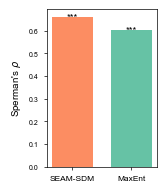

In [6]:
# Plot bar chart for Spearman correlations (DeepSDM vs MaxEnt) and their significance.
fig, ax = plt.subplots(figsize = mm2inch(40, 50), gridspec_kw = {'left': 0.25, 'right': 0.95, 
                                                               'bottom': 0.15, 'top': 0.95})
ax.bar(['SEAM-SDM', 'MaxEnt'], [rho_cosine_deepsdm, rho_cosine_maxent], color = ['#fc8d62', '#66c2a5'], width = 0.7)

ax.set_ylabel(rf"Sperman's $\rho$")
ax.text(0, rho_cosine_deepsdm, get_significance_stars(p_cosine_deepsdm), ha = 'center', va = 'center', size = 7)
ax.text(1, rho_cosine_maxent, get_significance_stars(p_cosine_maxent), ha = 'center', va = 'center', size = 7)
ax.tick_params('x', labelsize = 6)

plot_output = os.path.join(PU.plot_path_nichespace, 'rho_bar_cosine_similarity.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

## Indicator comparison

In [7]:
# Merge performance indicator data from multiple CSV files (constant threshold or multi-threshold).
# This allows for a side-by-side comparison of model performance across different evaluation metrics.
indicator_merged = PU.merge_performance_indicator()

In [8]:
# Prepare data for performance metrics comparisons.
# data_deepsdm, data_maxent: lists of metric values.
# ticks: metric names, significance_stars: results of statistical tests for difference.
data_deepsdm, data_maxent, ticks, significance_stars, n, t_stats, p_values = get_performance_stats(indicator_merged)

In [9]:
print(f'{len(data_deepsdm[0])}, {len(data_deepsdm[1])}, {len(data_deepsdm[2])}, {len(data_deepsdm[3])}')
print(ticks)
print(t_stats)
print(p_values)

20912, 15566, 20155, 20155
['AUC', 'F1', 'TSS', "Cohen's Kappa"]
[72.85528431803861, 54.985362307567534, 78.86626017183053, 78.79469376341139]
[0.0, 0.0, 0.0, 0.0]


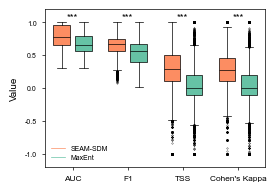

In [10]:
# Create a comparative boxplot for metrics like AUC, F1, TSS, and Kappa.
# The boxplot displays distribution of performance for DeepSDM vs. MaxEnt, along with significance.
color_deepsdm = '#fc8d62'
color_maxent = '#66c2a5'

# Function to set the box color and styling.
def set_box_color(bp, fill_color):
    for patch in bp['boxes']:
        patch.set_edgecolor('black')
        patch.set_facecolor(fill_color)
    for whisker in bp['whiskers']:
        whisker.set_color('black')
    for cap in bp['caps']:
        cap.set_color('black')
    for median in bp['medians']:
        median.set_color('black')

positions_deepsdm = np.array(range(len(data_deepsdm))) * 2.0 - 0.4
positions_maxent = np.array(range(len(data_maxent))) * 2.0 + 0.4

fig, ax = plt.subplots(figsize=mm2inch(70, 50), gridspec_kw = {'left': 0.15, 'right': 0.95, 
                                                               'bottom': 0.15, 'top': 0.95})

bpl = ax.boxplot(data_deepsdm, positions=positions_deepsdm, sym='.', widths=0.6, patch_artist=True)
bpr = ax.boxplot(data_maxent, positions=positions_maxent, sym='.', widths=0.6, patch_artist=True)

set_box_color(bpl, color_deepsdm)
set_box_color(bpr, color_maxent)

for i, star in enumerate(significance_stars):
    x_pos = (positions_deepsdm[i] + positions_maxent[i]) / 2
    y_max = max(np.max(data_deepsdm[i]), np.max(data_maxent[i]))
    ax.text(x_pos, y_max + 0.02, star, ha='center', va='bottom', fontsize=7, color='black')

ax.plot([], c = color_deepsdm, label = 'SEAM-SDM')
ax.plot([], c = color_maxent, label = 'MaxEnt')
ax.legend(loc = 'lower left')
ax.set_xticks(range(0, len(ticks) * 2, 2))
ax.set_xticklabels(ticks, fontsize = 6)
ax.set_xlim(-1, len(ticks) * 2 - 1)
ax.set_ylabel('Value')
ax.set_ylim(-1.2, 1.2)
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_yticklabels(np.arange(-1, 1.1, 0.5))
ax.grid(False)

plot_output = os.path.join(PU.plot_path_nichespace, 'indicator_boxplot_constantthreshold.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)

plt.show()

## Plot model predictions and occurrence map

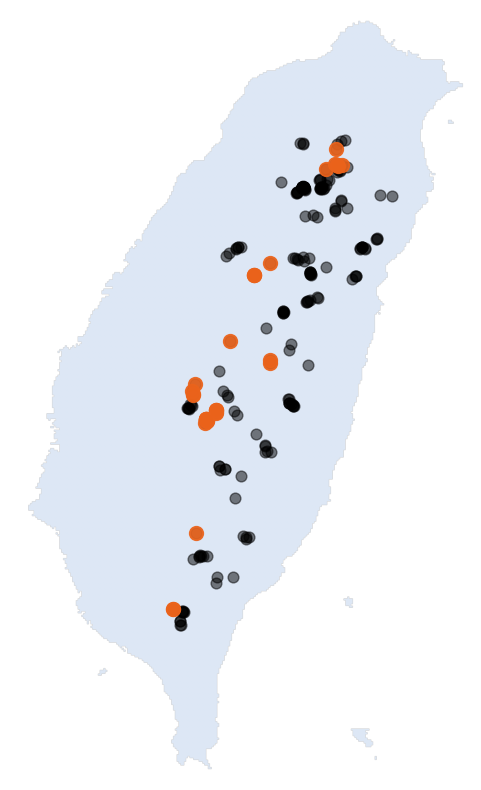

In [13]:
species = ['Chamaecyparis_formosensis']
dates = ['2003-01-01']
models = ['DeepSDM']

maxmin_sp = {}
subplot_folder = os.path.join(PU.plot_path_nichespace, 'subplots')
create_folder(subplot_folder)

def log_value(data, species, model):
    key = f'{species}_{model}'
    max_val, min_val = np.nanmax(data), np.nanmin(data)
    if key not in maxmin_sp:
        maxmin_sp[key] = [min_val, max_val]
    else:
        maxmin_sp[key][0] = min(maxmin_sp[key][0], min_val)
        maxmin_sp[key][1] = max(maxmin_sp[key][1], max_val)

def read_data(path, species, date):
    with h5py.File(path.replace('[SPECIES]', species), 'r') as hf:
        return hf[date][:]

for s in species:
    for d in dates:
        for model in models:
            path = PU.deepsdm_h5_path if model == 'DeepSDM' else PU.maxent_h5_path
            img = read_data(path, s, d)
            log_value(img, s, model)

for s in species:
    for d in dates:
        for model in models:
            path = PU.deepsdm_h5_path if model == 'DeepSDM' else PU.maxent_h5_path
            img = read_data(path, s, d)
            vmax, vmin = maxmin_sp[f'{s}_{model}'][1], maxmin_sp[f'{s}_{model}'][0]

            fig, ax = plt.subplots(figsize=(6, 10))
            ax.imshow(img, cmap='coolwarm', extent=PU.extent_binary_extent, vmax=vmax, vmin=vmin)
            ax.axis('off')

            output_path = os.path.join(subplot_folder, f'{s}_{d}_{model.lower()}.pdf')
            plt.savefig(output_path, dpi=500, transparent=True, bbox_inches='tight')
            plt.close()
            
        # Occurrence plot
        year, month = map(int, d.split('-')[:2])
        occ_all = PU.species_occ[PU.species_occ['species'] == s]
        occ_time = occ_all[(occ_all['year'] == year) & (occ_all['month'] == month)]

        fig, ax = plt.subplots(figsize=(6, 10))
        ax.imshow(np.where(PU.extent_binary == 0, np.nan, PU.extent_binary), cmap=ListedColormap(['#AAC4E7']), extent=PU.extent_binary_extent, alpha=0.4)
        ax.scatter(occ_all['decimalLongitude'], occ_all['decimalLatitude'], color='#000000', s=60, alpha=0.5)
        ax.scatter(occ_time['decimalLongitude'], occ_time['decimalLatitude'], color='#EB631B', s=100, alpha=0.9)
        ax.axis('off')

        output_path = os.path.join(subplot_folder, f'{s}_{d}_occ.pdf')
        # plt.savefig(output_path, dpi=500, transparent=True, bbox_inches='tight')
        # plt.close()